### Notebook setup

In [2]:
import joblib
import pandas as pd
import deepchem as dc
import matplotlib.pyplot as plt
from xgboost import plot_importance
import numpy as np
from rdkit.Chem import rdFingerprintGenerator

model = joblib.load("../models/mejor_modelo_lrrk2_scaffold.pkl")

2026-03-12 18:49:34.954075: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 18:49:35.046900: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 18:49:36.951738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


### Features más importantes

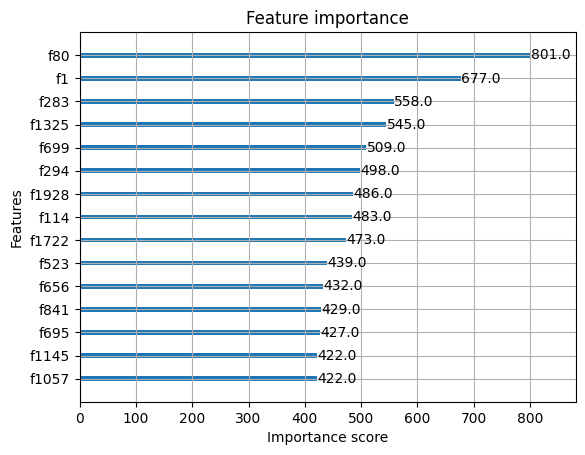

In [16]:
plot_importance(model, max_num_features=15) # Muestra las 15 más relevantes
plt.show()

### Cargamos datos de moléculas para visualizarlas

In [17]:
import warnings

# Suppress only deprecation warnings
warnings.filterwarnings("ignore")

In [ ]:
featurizer = dc.feat.CircularFingerprint(size=2048, radius=2)
loader = dc.data.CSVLoader(tasks=["Score"], feature_field="SMILES", featurizer=featurizer)
dataset = loader.create_dataset("../data/hits_lrrk2_zinc15.csv")

In [5]:
df = pd.DataFrame(dataset.X, index=dataset.ids)
df

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
CO[C@H](C)CCC(=O)N[C@]12CCC[C@H]1CN(c1cc(F)ncn1)C2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCNc1cc(N2C[C@H]3CCC[C@@]3(c3nc(C)no3)C2)ncn1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CCc1nc(C)cc(N2CC[C@H]3[C@@H]2CCCN3C(=O)C2(C)CC2)n1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C[C@@H](C(=O)NC[C@]1(C)CCCN(c2cc(F)ncn2)C1)c1ccco1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cc1cc(N2CC3(CCC3)[C@H]2c2cccnc2)nc(CO)n1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
O=C(Nc1nccc(C2CC2)n1)c1cc2c(s1)CCOC2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NCc1cccc(C(=O)Nc2ccc(N3CCCC3)nc2)c1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cc1nc(CNC[C@]23CCC[C@H]2CN(C(=O)[C@H]2CCCN2C)C3)n[nH]1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CC1(C(=O)N2CC[C@@]3(CCN(Cc4cc5n(n4)CCC5)C3)C2)CCC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Estudiamos qué representa el bit 80 (el más importante para nuestro modelo)

In [6]:
df_bit = df[df[80] == 1]
df_bit.iloc[0]

0       0.0
1       1.0
2       0.0
3       0.0
4       0.0
       ... 
2043    0.0
2044    0.0
2045    0.0
2046    0.0
2047    0.0
Name: CO[C@H](C)CCC(=O)N[C@]12CCC[C@H]1CN(c1cc(F)ncn1)C2, Length: 2048, dtype: float64

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

def analizar_bit(bit_id):
    df_bit = df[df[bit_id] == 1]
    for i in range(5):
        # 1. Elegid una molécula de vuestro dataset que tenga ese bit activo
        selected = df_bit.iloc[i]
        smiles = selected.name
        mol = Chem.MolFromSmiles(smiles)
        
        # 2. Necesitamos un diccionario para guardar la información del fragmento
        bit_info = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bit_info)
    
        # 3. Visualizar el fragmento del bit "f80" (en RDKit es el ID 80)
        # Esto generará una imagen del átomo central y su entorno
        options = Draw.MolDrawOptions()
        options.addAtomIndices = False     # Ponlo en True si quieres ver el número de cada átomo
        options.addStereoAnnotation = True # Muestra si es R/S (estereoquímica)
        options.prepareMolsBeforeDrawing = True
        options.fixedFontSize = 20
        img = Draw.DrawMorganBit(mol, bit_id, bit_info, drawOptions=options)
        plt.imshow(img)
        plt.show()
        img = Draw.MolToImage(mol, highlightAtoms=[bit_info[bit_id][0][0]], size=(400, 400))
        plt.imshow(img)
        plt.show()

[17:50:27] DEPRECATION WARNING: please use MorganGenerator


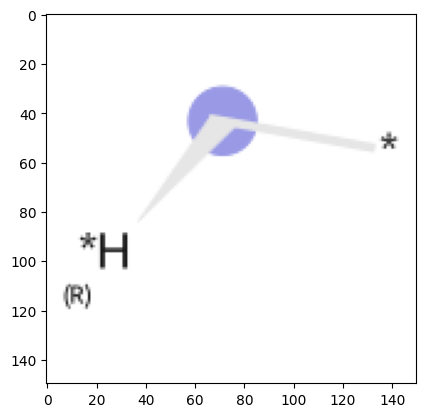

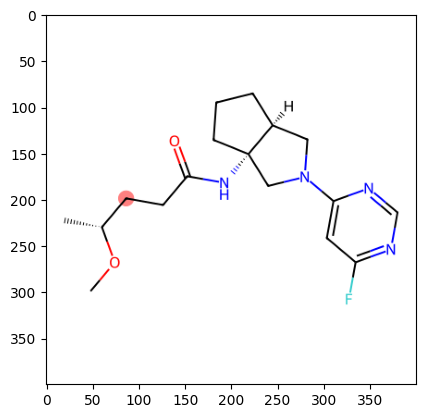

[17:50:27] DEPRECATION WARNING: please use MorganGenerator


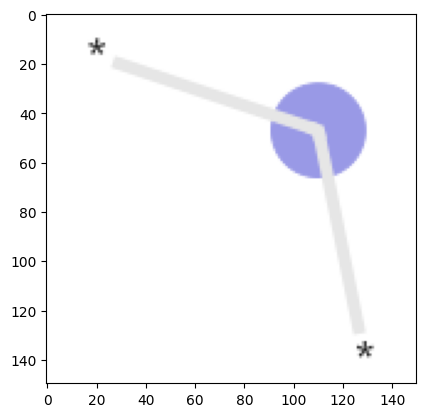

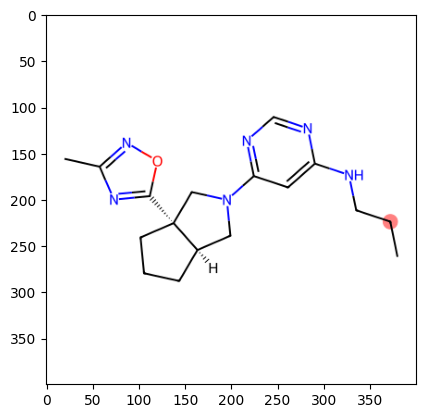

[17:50:28] DEPRECATION WARNING: please use MorganGenerator


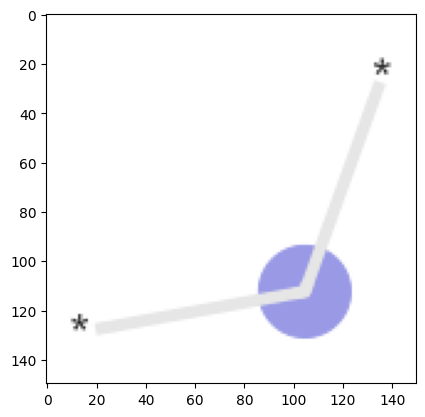

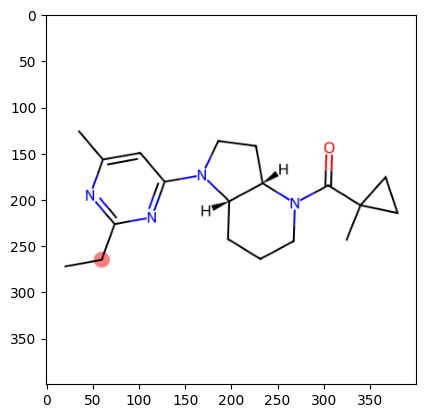

[17:50:28] DEPRECATION WARNING: please use MorganGenerator


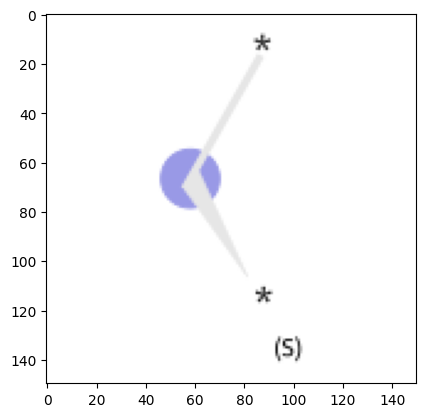

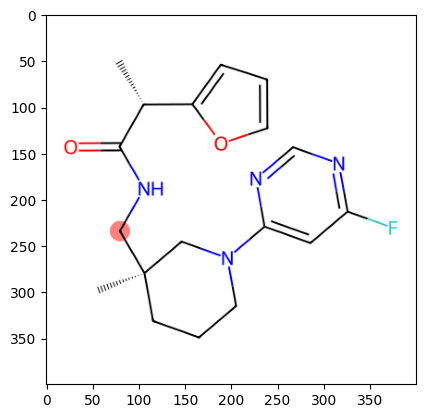

[17:50:28] DEPRECATION WARNING: please use MorganGenerator


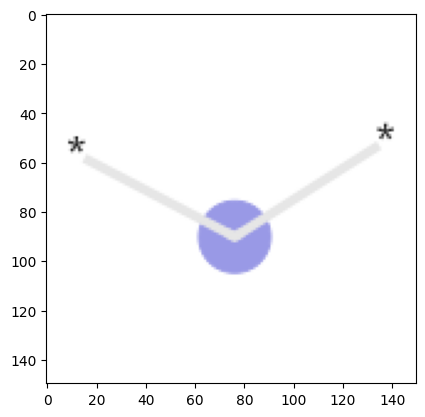

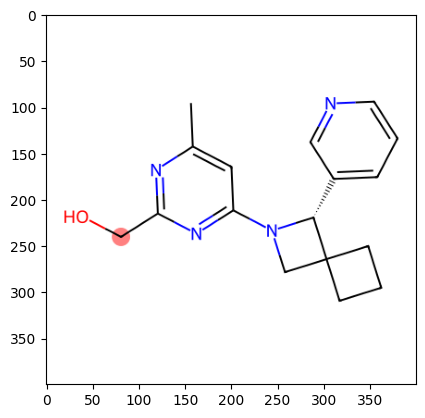

In [8]:
analizar_bit(80)

[17:51:11] DEPRECATION WARNING: please use MorganGenerator


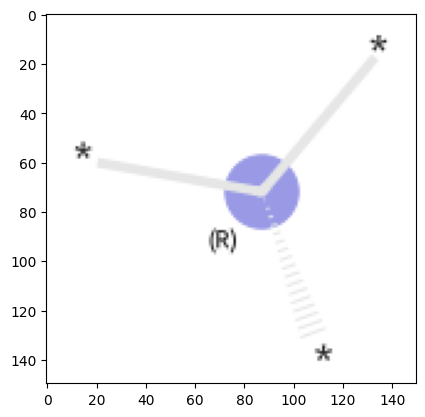

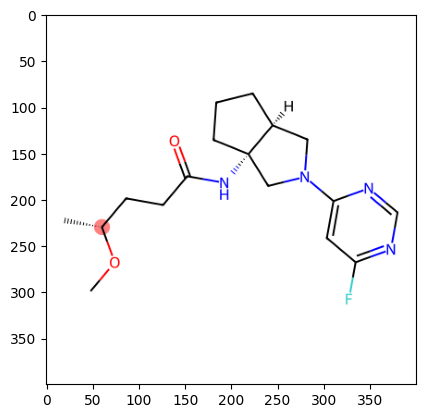

[17:51:12] DEPRECATION WARNING: please use MorganGenerator


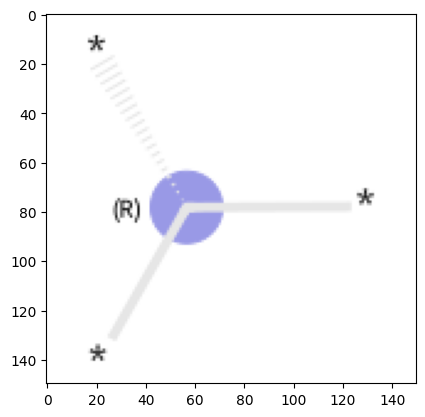

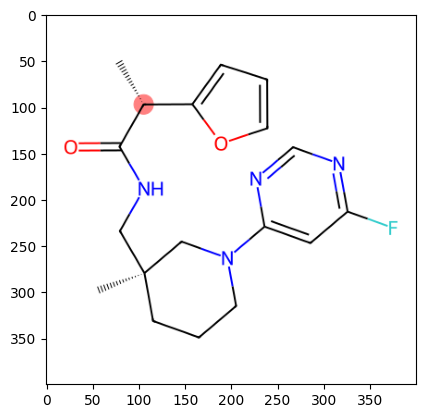

[17:51:12] DEPRECATION WARNING: please use MorganGenerator


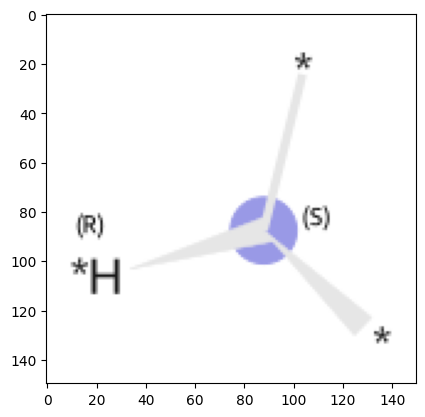

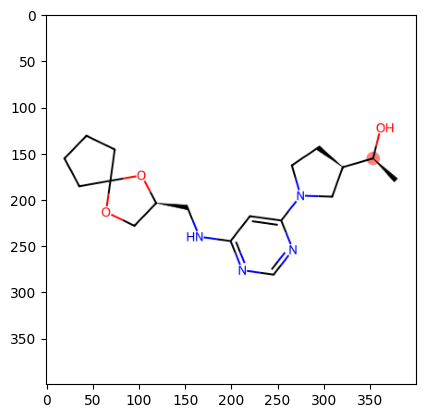

[17:51:13] DEPRECATION WARNING: please use MorganGenerator


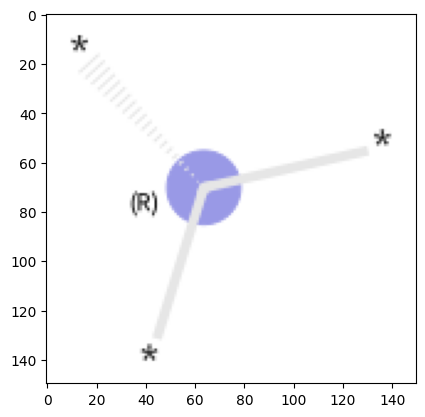

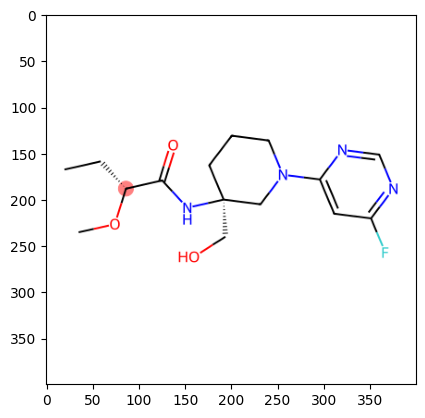

[17:51:13] DEPRECATION WARNING: please use MorganGenerator


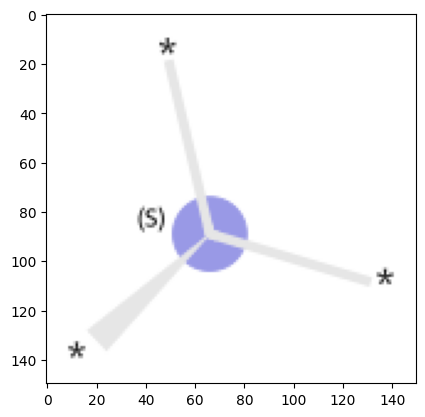

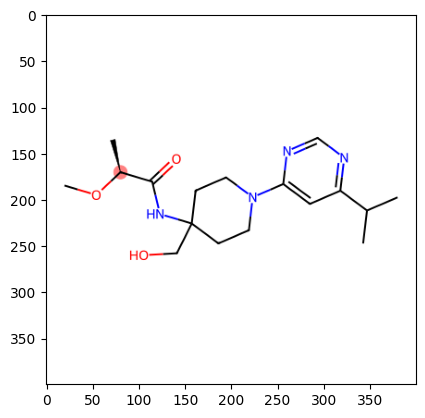

In [9]:
analizar_bit(1)

# Visualización de Arbol Individual

/home/alfon/.pyenv/versions/miniconda3-latest/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


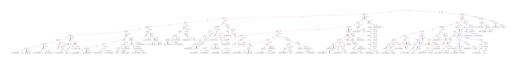

In [7]:
from xgboost import plot_tree

# Visualiza el primer árbol del modelo
plot_tree(model, num_trees=0)
plt.savefig("tree.jpg")

In [3]:
import xgboost as xgb

graph = xgb.to_graphviz(model, num_trees=0)
graph.render("arbol_lrrk2_detalle", format="pdf")

/home/alfon/.pyenv/versions/miniconda3-latest/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


'arbol_lrrk2_detalle.pdf'